# Segmentación de clientes con K-Means

En este documento puedes desarrollar el eunciado adjunto (contiene algunas pistas y preguntas adicionales)

## Objetivos
- Comprender qué es clustering.
- Aplicar K-Means.
- Elegir el número óptimo de clusters.
- Interpretar los resultados.

## Pregunta Inicial
**¿Podemos identificar tipos de clientes según su comportamiento?**

## Descripción de las columnas
- **CustomerID**: Identificador único de cada cliente. No es relevante para el clustering, ya que no aporta información útil para la segmentación.
- **Genre**: Género del cliente (Male/Female). En algunos casos puede ser útil si se convierte a valores numéricos, aunque K-Means trabaja mejor con variables numéricas continuas.
- **Age**: Edad del cliente. Puede ser un factor clave en la segmentación, ya que distintos grupos de edad pueden tener diferentes patrones de gasto.
- **Annual Income (k$)**: Ingreso anual del cliente en miles de dólares. Es un indicador relevante para clasificar clientes en función de su poder adquisitivo.
- **Spending Score (1-100)**: Puntuación asignada a cada cliente según sus hábitos de gasto y comportamiento de compra (por ejemplo, un puntaje alto puede indicar que el cliente gasta mucho en relación con su ingreso).

## 1. Carga de datos

In [1]:
# Importando librerias
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ClientesCentroComercial.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 2. Exploración inicial

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [3]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Cuestiones
1. ¿Qué variables te parecen más útiles para agrupar clientes?
    - Las variables mas útiles son el ingreso anual y la cantidad de gastos
2. ¿Hay alguna variable que no tenga sentido usar?
    - El ID, ya que no aporta ninguna información, la edad porque clasificaría a los clientes según la edad y no por sus hábitos de consumo / gasto. Y por último el género, nos aportaria diferencias de comportamiento entre géneros, pero no entre ganancia y gastos

## 3. Selección de variables

Vamos a trabajar con dos variables especialmente útiles para segmentar clientes:
- **Annual Income (k$)**
- **Spending Score (1-100)**

In [4]:
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Recuerda:** estamos usando variables relacionadas con capacidad económica y comportamiento de compra.

## 4. Visualización inicial

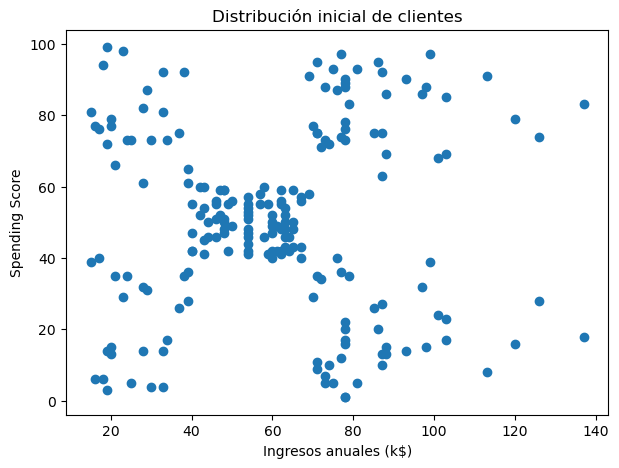

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1])
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Spending Score")
plt.title("Distribución inicial de clientes")
plt.show()

## Cuestión
**¿Observas posibles grupos de clientes a simple vista?**

    - A simple vista podemos observar 5 grupos, ya que se ven indicados de forma clara, como si fuese un 5 en un dado.

## 5. Escalado de datos

**Importante:** K-Means utiliza distancias.  
Por eso, antes de aplicar el algoritmo, conviene poner las variables en la misma escala.

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# COMPLETAR
X_scaled = scaler.fit_transform(X)

## 6. Método del codo

Ahora vamos a probar distintos valores de **K** para decidir cuántos clusters conviene usar.

In [7]:

from sklearn.cluster import KMeans

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)

    # COMPLETAR
    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

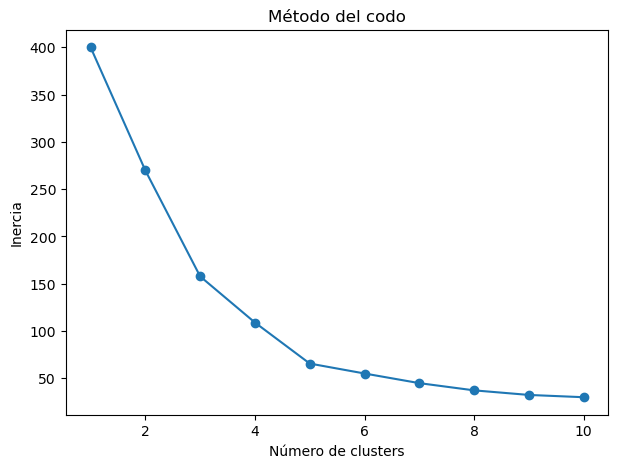

In [8]:
plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inercia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## Cuestiones
1. ¿En qué valor de **K** parece producirse el “codo”?
2. ¿Por qué ese punto puede considerarse un buen compromiso?

## 7. Aplicación de K-Means

In [9]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

# COMPLETAR
clusters = kmeans.fit_predict(X_scaled)

In [10]:
# Viendo el silhouette score
from sklearn.metrics import silhouette_score
score = silhouette_score(X_scaled, clusters)
print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.5547


## 8. Visualización de clusters

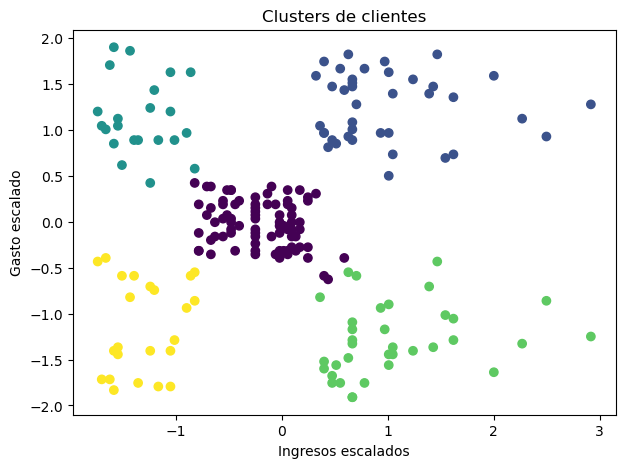

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters de clientes")
plt.show()

## 9. Centroides

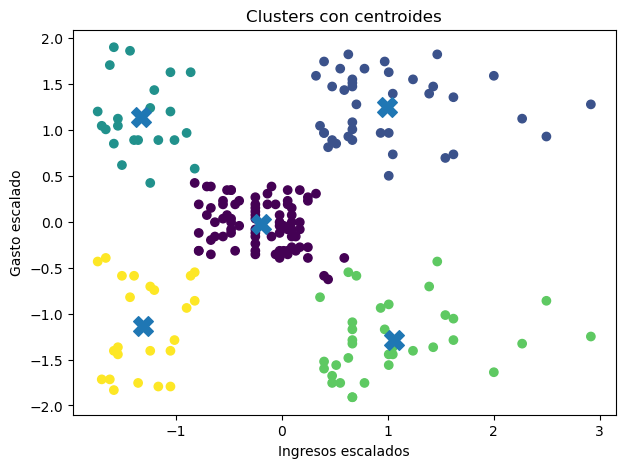

In [12]:
centroides = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.show()

## 10. Interpretación de resultados

Añade una nueva columna al DataFrame con el cluster asignado a cada cliente.

In [13]:
# COMPLETAR
df["cluster"] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [14]:
df.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Cuestiones
1. ¿Qué tipo de clientes representa cada cluster?
    - En mi caso me he decantado por 5 clústers, ya que a simple vista se podían distinguir, se puede también razonar esta division y por último el método del codo dejaba el rango entre 3 y 5 (pendiente algo peor, pero pronunciada). Para poder describir cada clúster, deberemos de basarnos en la media de cada clúster y también nos apoyaremos en la representación gráfica
        - El primer clúster es el que cuenta con gente que gana muy poco dinero y que gastan muy poco dinero (clase baja)
        - El segundo clúster es aquel el cuenta con pocos ingresos y gastan mucho (descerebrados)
        - El tercer clúster es aquel que cuenta con ingresos medios, y que gastan de forma moderada (clase media)
        - El cuarto cluster es aquel que indica a los clientes que cuentan con muchos ingresos pero que no gastan casi dinero (ratas).
        - El quinto cluster es aquel que indica a los clientes que ganan mucho dinero pero que también gastan mucho dinero (despilfarradores).
2. ¿Cuál te parece más interesante para el negocio?
    - Para el negocio es interesante que los grupos cuyos gastos son bajos se incrementen y que los que gastan mucho sigan gastando lo mismo o más, para asi poder aumentar los beneficios.
3. ¿Qué estrategia comercial podría aplicarse a cada grupo?
    - En este caso, deberemos de aplicar distintas estrategias para cada grupo, ya que estos cuentan con distintos ingresos y necesidades.
        - En el primer cluster, para aquellos que ganan poco y gastan poco, podremos hacer algún descuento de bienvenida
        - En el segundo cluster, podemos darles algún descuento pequeño por cada compra para seguir incitandolos a gastar más o lo mismo
        - En el tercer clúster, 
        - En el cuarto clúster, 
        - En el quinto clúster, podremos hacer una tarjeta o distincion a los clientes VIP, para que cuenten con alguna ventaja respecto al resto de clientes.
4. ¿Qué pasaría si no hubiéramos escalado los datos?
    - El modelo sería incorrecto, ya que los variables mayores dominarian el modelo, lo cual afectarían al rendimiento, lo cual sería un modelo incorrecto.
5. ¿K-Means siempre encuentra los mejores grupos?
    - No, ya que los resultados de K-Means cambian según se colocan los centroides, ya que esto ocurre de forma aleatoria. Esto es algo negativo ya que el modelo podria quedarse en mínimos locales.
6. ¿Qué limitaciones tiene este algoritmo?
    - Las principales limitaciones son: la sensibilidad a los outliers, la definición del número de clústers (k) y por último, las formas irregulares de los clústers. Para prevenir estos problemas se suele cambiar a modelos como el DBSCAN que aunque sean algo mas exigentes computacionalmente, sus resultados son mejores.

## 11. Opcional

Prueba a repetir el análisis añadiendo la variable **Age**.

Preguntas:
- ¿Cambian los clusters?
- ¿Son más realistas o más difíciles de interpretar?

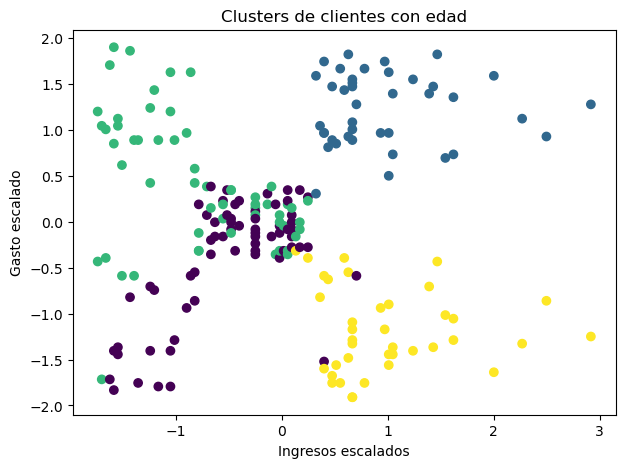

In [15]:
X_edad = df[["Annual Income (k$)", "Spending Score (1-100)", "Age"]]
X_edad.head()

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# COMPLETAR
X_edad = scaler.fit_transform(X_edad)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# COMPLETAR
clusters = kmeans.fit_predict(X_edad)

# Representando los clusters con las nuevas características
plt.figure(figsize=(7,5))
plt.scatter(X_edad[:, 0], X_edad[:, 1], c=clusters)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters de clientes con edad")
plt.show()

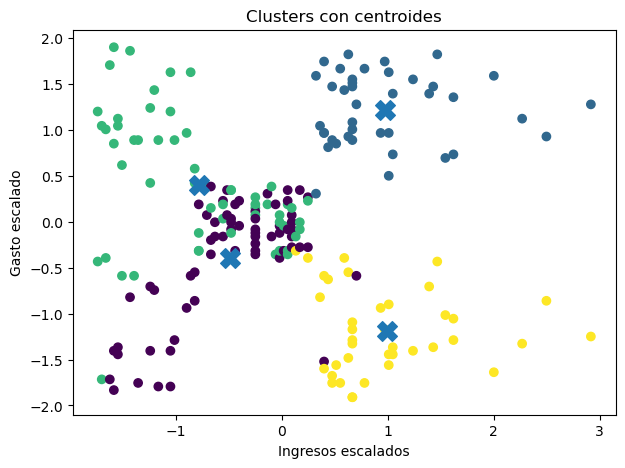

In [16]:
centroides = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_edad[:, 0], X_edad[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.show()

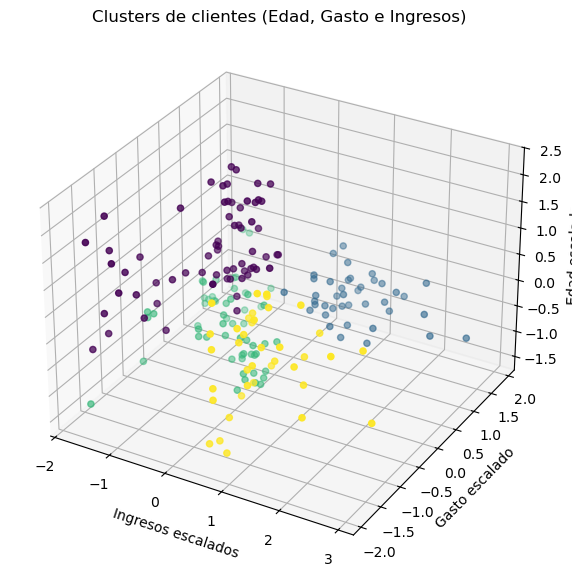

In [17]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_edad[:, 0], X_edad[:, 1], X_edad[:, 2], c=clusters)

ax.set_xlabel("Ingresos escalados")
ax.set_ylabel("Gasto escalado")
ax.set_zlabel("Edad escalada")
ax.set_title("Clusters de clientes (Edad, Gasto e Ingresos)")

plt.show()

In [18]:
df_edad = pd.read_csv("ClientesCentroComercial.csv")

df_edad["cluster"] = clusters
df_edad.head()

df_edad.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)", "Age"]].mean()

,Annual Income (k$),Spending Score (1-100),Age
cluster,,,
0,47.707692,39.969231,53.984615
1,86.100000,81.525000,32.875000
2,40.000000,60.298246,25.438596
3,86.500000,19.578947,39.368421
